In [1]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 1.5 MB/s  0:00:12a 0:00:010:00:01:02

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="superstore"
)


In [26]:
sales_by_region = "SELECT region, SUM(sales) AS total_sales FROM data GROUP BY region"

df = pd.read_sql(sales_by_region, conn)
print(df)

    region  total_sales
0    South  388983.5850
1     West  713471.3445
2  Central  497800.8728
3     East  672194.0540


/var/folders/83/z2r1_lkd19v2k3mz86vw9lr00000gp/T/ipykernel_3824/4078625275.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sales_by_region, conn)


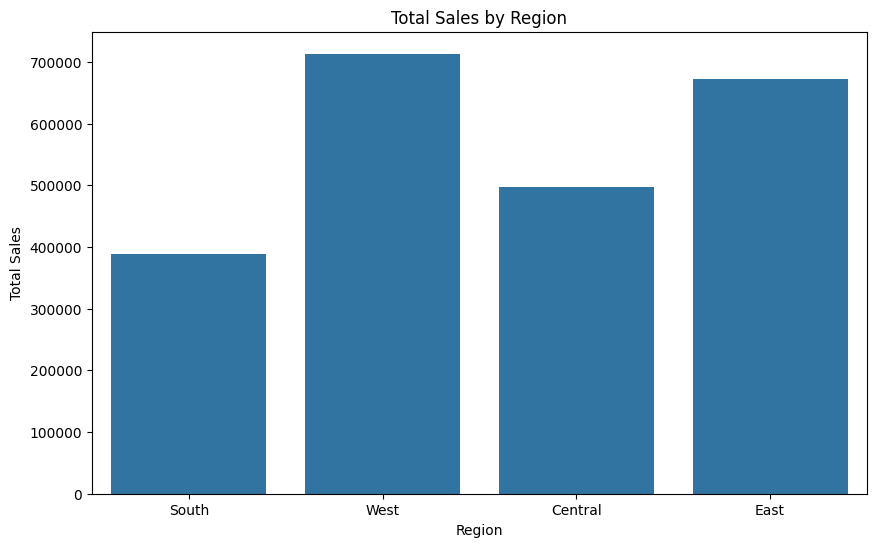

In [33]:
# Bar chart

plt.figure(figsize = (10,6))
plt.title("Total Sales by Region")
sns.barplot(data = df, x = "region", y = "total_sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [56]:
profitable_products = """select `product name` as profitable_products, round(sum(profit),2) as total_profit 
from data 
group by `product name`
order by total_profit desc 
limit 10;"""

df = pd.read_sql(profitable_products, conn)
print(df)

                                 profitable_products  total_profit
0              Canon imageCLASS 2200 Advanced Copier      25199.93
1  Fellowes PB500 Electric Punch Plastic Comb Bin...       7753.04
2               Hewlett Packard LaserJet 3310 Copier       6983.88
3                 Canon PC1060 Personal Laser Copier       4570.93
4  HP Designjet T520 Inkjet Large Format Printer ...       4094.98
5                  Ativa V4110MDD Micro-Cut Shredder       3772.95
6   3D Systems Cube Printer, 2nd Generation, Magenta       3717.97
7  Plantronics Savi W720 Multi-Device Wireless He...       3696.28
8               Ibico EPK-21 Electric Binding System       3345.28
9                  Zebra ZM400 Thermal Label Printer       3343.54


/var/folders/83/z2r1_lkd19v2k3mz86vw9lr00000gp/T/ipykernel_3824/409320235.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(profitable_products, conn)


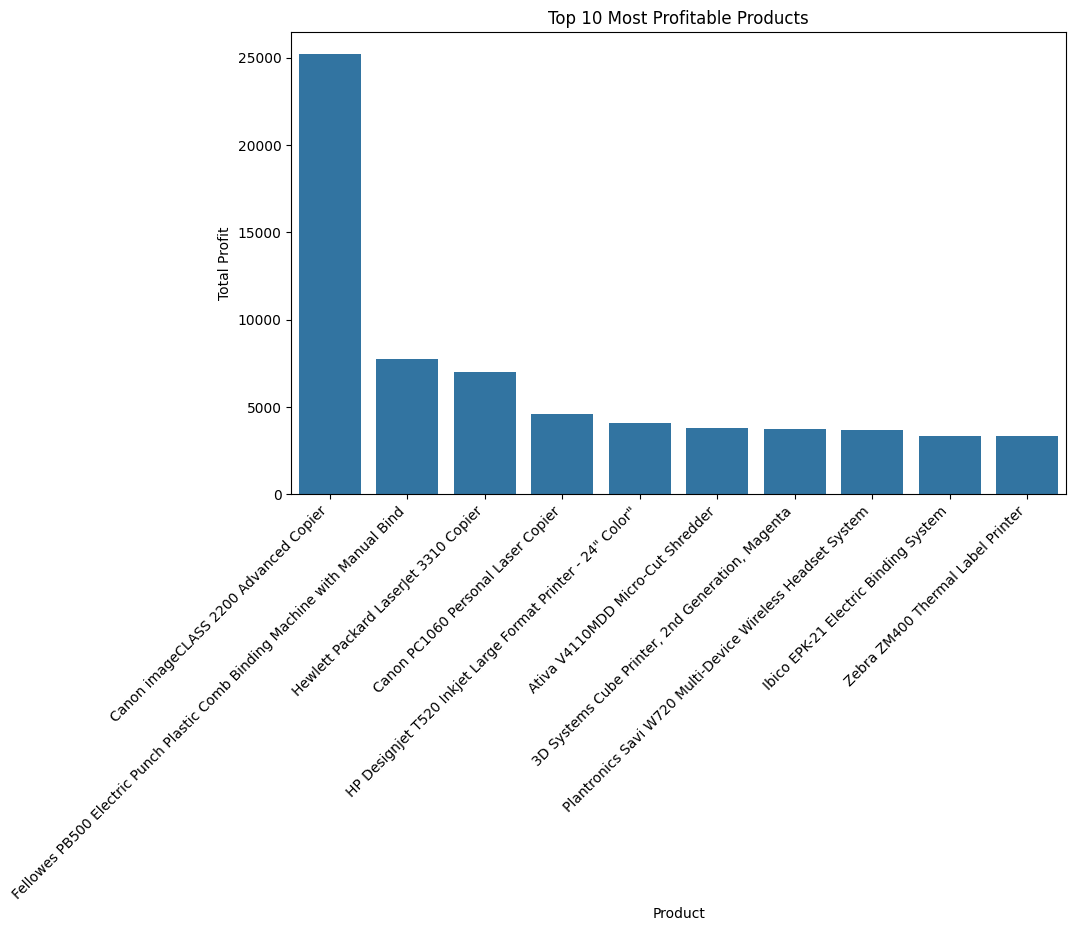

In [61]:
# Bar chart

plt.figure(figsize = (10,6))
plt.title("Top 10 Most Profitable Products")
sns.barplot(data = df, x = "profitable_products", y = "total_profit")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha='right')
plt.show()

# print(df.columns)

In [36]:
monthly_sales_trend = """select YEAR(STR_TO_DATE(`order date`, '%d-%m-%Y')) AS YearNum, 
MONTH(STR_TO_DATE(`order date`, '%d-%m-%Y')) AS MonthNum,        
round(sum(sales)) as total_sales
from data 
group by yearnum, monthnum
order by yearnum, monthnum;"""

df = pd.read_sql(monthly_sales_trend, conn)
print(df)

    YearNum  MonthNum  total_sales
0      2011         1      13871.0
1      2011         2       4410.0
2      2011         3      55526.0
3      2011         4      28140.0
4      2011         5      23635.0
5      2011         6      34509.0
6      2011         7      33501.0
7      2011         8      27604.0
8      2011         9      81497.0
9      2011        10      31395.0
10     2011        11      78297.0
11     2011        12      69380.0
12     2012         1      18085.0
13     2012         2      12184.0
14     2012         3      38362.0
15     2012         4      32640.0
16     2012         5      29326.0
17     2012         6      24660.0
18     2012         7      28525.0
19     2012         8      36381.0
20     2012         9      63704.0
21     2012        10      31382.0
22     2012        11      74699.0
23     2012        12      74478.0
24     2013         1      18433.0
25     2013         2      22595.0
26     2013         3      50303.0
27     2013         

/var/folders/83/z2r1_lkd19v2k3mz86vw9lr00000gp/T/ipykernel_3824/1092663110.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(monthly_sales_trend, conn)


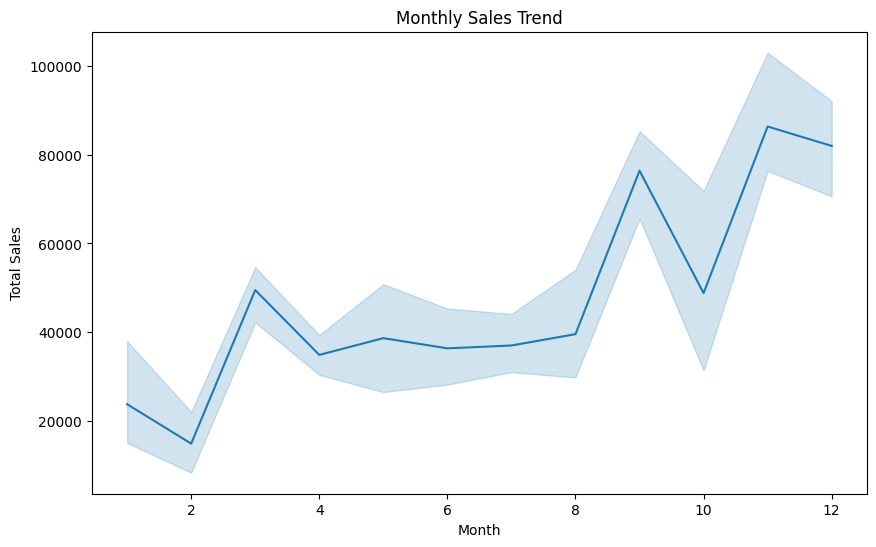

In [41]:
# Line chart

plt.figure(figsize = (10,6))
plt.title("Monthly Sales Trend")
sns.lineplot(data = df, x = "MonthNum", y = "total_sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show() 

In [46]:
most_order_category = """select category, count(*) as total_quantity 
from data 
group by category 
order by total_quantity desc;"""

df = pd.read_sql(most_order_category, conn)
print(df)

          category  total_quantity
0  Office Supplies            5781
1        Furniture            2074
2       Technology            1839


/var/folders/83/z2r1_lkd19v2k3mz86vw9lr00000gp/T/ipykernel_3824/80137512.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(most_order_category, conn)


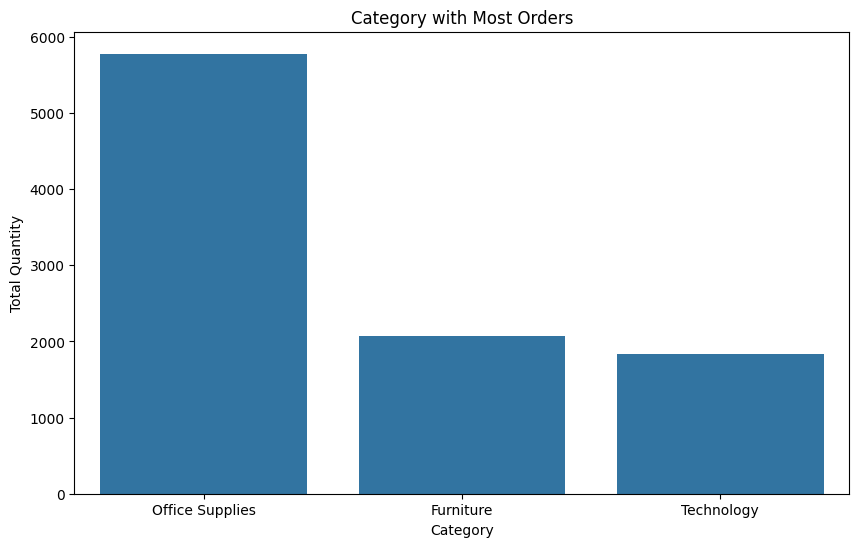

In [48]:
# Bar chart

plt.figure(figsize = (10,6))
plt.title("Category with Most Orders")
sns.barplot(data = df, x = "category", y = "total_quantity")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.show()

# print(df.columns)

In [49]:
bottom_5_states = """select state, round(sum(profit),2)  as total_profit
from data 
group by state
order by total_profit asc
limit 5;"""

df = pd.read_sql(bottom_5_states , conn)
print(df)

            state  total_profit
0           Texas     -25534.99
1            Ohio     -17071.22
2    Pennsylvania     -15446.38
3        Illinois     -12031.07
4  North Carolina      -7486.90


/var/folders/83/z2r1_lkd19v2k3mz86vw9lr00000gp/T/ipykernel_3824/910820135.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(bottom_5_states , conn)


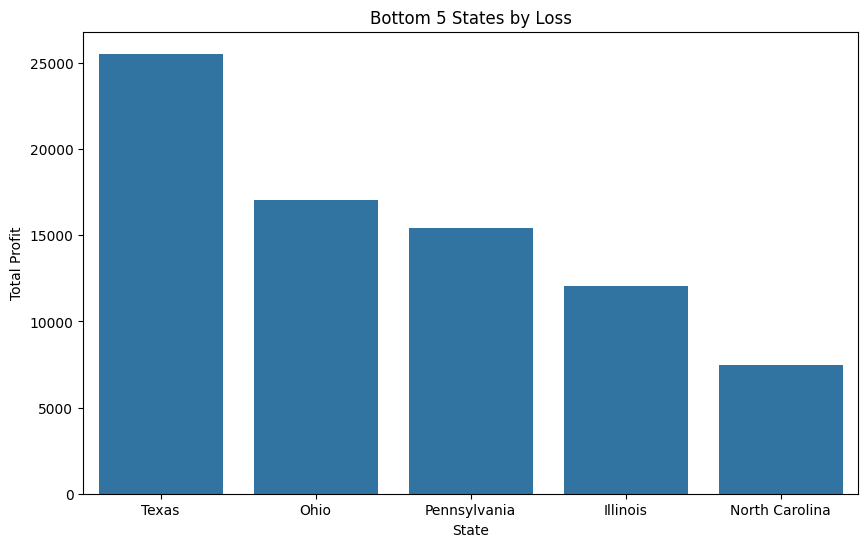

In [55]:
df['total_profit'] = df['total_profit'].abs()

# Bar chart

plt.figure(figsize = (10,6))
plt.title("Bottom 5 States by Loss")
sns.barplot(data = df, x = "state", y = "total_profit")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.show()

# print(df.columns)